In [1]:
import sys
import os
import warnings
from datetime import datetime, timezone, timedelta
from pathlib import Path
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pytz
import json
from zoneinfo import ZoneInfo
from pandas import Timestamp
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from scipy.stats import norm

current_dir = Path.cwd()
parent_dir = current_dir.parent
sys.path.insert(0, str(parent_dir))
from lib import *

MODEL_PATH=parent_dir / 'models' 
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1000)

In [2]:
example_ticker = "KXBTC15M-26MAY040515-15"
lookback_minutes = 8000
series, event_dt = parse_kalshi_15m_event_ticker(example_ticker)
dt_only = get_ticker_datetime(example_ticker)
# crypto_at = datetime(2026,5,5,0,0,tzinfo=ZoneInfo('America/Chicago'))
crypto_at = datetime.now(tz=ZoneInfo('America/Chicago'))
df_api = get_market_data_from_api(series, crypto_at, lookback_minutes)
df_api = df_api.set_index('datetime')
df_api.head()

Error getting market candlesticks: 'floor_strike'
API Error Response: {'error': {'code': 'not_found', 'message': 'not found', 'service': 'query-exchange'}}
Error getting market candlesticks: 404 Client Error: Not Found for url: https://api.elections.kalshi.com/trade-api/v2/series/KXBTC15M/markets/KXBTC15M-26MAY070215-15/candlesticks?series_ticker=KXBTC15M&ticker=KXBTC15M-26MAY070215-15&start_ts=1778133300&end_ts=1778134500&period_interval=1&include_latest_before_start=True&limit=1000
API Error Response: {'error': {'code': 'not_found', 'message': 'not found', 'service': 'query-exchange'}}
Error getting market candlesticks: 404 Client Error: Not Found for url: https://api.elections.kalshi.com/trade-api/v2/series/KXBTC15M/markets/KXBTC15M-26MAY070230-30/candlesticks?series_ticker=KXBTC15M&ticker=KXBTC15M-26MAY070230-30&start_ts=1778134200&end_ts=1778135400&period_interval=1&include_latest_before_start=True&limit=1000
API Error Response: {'error': {'code': 'not_found', 'message': 'not foun

,ticker,floor_strike,yes_ask_low_dollar,yes_bid_high_dollar,no_ask_low_dollar,no_bid_high_dollar
datetime,,,,,,
2026-05-03 09:46:00-05:00,KXBTC15M-26MAY031100-00,78702.85,0.49,0.55,0.84,0.00
2026-05-03 09:47:00-05:00,KXBTC15M-26MAY031100-00,78702.85,0.38,0.50,0.63,0.48
2026-05-03 09:48:00-05:00,KXBTC15M-26MAY031100-00,78702.85,0.36,0.47,0.65,0.51
2026-05-03 09:49:00-05:00,KXBTC15M-26MAY031100-00,78702.85,0.14,0.37,0.87,0.62
2026-05-03 09:50:00-05:00,KXBTC15M-26MAY031100-00,78702.85,0.15,0.28,0.86,0.71


In [3]:
df_crypto = get_crypto_past_minutes(series, crypto_at, lookback_minutes)
df_crypto['datetime'] = pd.to_datetime(df_crypto['datetime'])
df_crypto['datetime'] = df_crypto['datetime'].dt.tz_convert('America/Chicago')
df_crypto['datetime'] = df_crypto['datetime'].dt.floor('min')
df_crypto = df_crypto.set_index('datetime')
filter_timestamp = df_crypto[df_crypto.index.minute.isin([0,15,30,45])].index[0]
df_crypto = df_crypto[df_crypto.index >= filter_timestamp]
df_crypto.head()

,open,high,low,close,tick_count
datetime,,,,,
2026-05-03 20:30:00-05:00,78544.30,78544.30,78544.30,78544.30,0
2026-05-03 20:31:00-05:00,78583.26,78583.26,78583.26,78583.26,0
2026-05-03 20:32:00-05:00,78697.17,78697.17,78697.17,78697.17,0
2026-05-03 20:33:00-05:00,78925.09,79005.36,78892.57,79000.85,41
2026-05-03 20:34:00-05:00,78990.53,78990.53,78936.38,78936.38,0


In [4]:
df_merged = df_crypto.join(df_api, how='left')
df_merged = df_merged.dropna()
df_merged.head()

,open,high,low,close,tick_count,ticker,floor_strike,yes_ask_low_dollar,yes_bid_high_dollar,no_ask_low_dollar,no_bid_high_dollar
datetime,,,,,,,,,,,
2026-05-03 20:30:00-05:00,78544.30,78544.30,78544.30,78544.30,0,KXBTC15M-26MAY032130-30,78452.78,0.999,0.999,0.005,0.000
2026-05-03 20:31:00-05:00,78583.26,78583.26,78583.26,78583.26,0,KXBTC15M-26MAY032145-45,78573.32,0.540,0.907,1.000,0.090
2026-05-03 20:32:00-05:00,78697.17,78697.17,78697.17,78697.17,0,KXBTC15M-26MAY032145-45,78573.32,0.850,0.970,0.170,0.020
2026-05-03 20:33:00-05:00,78925.09,79005.36,78892.57,79000.85,41,KXBTC15M-26MAY032145-45,78573.32,0.949,0.986,0.060,0.013
2026-05-03 20:34:00-05:00,78990.53,78990.53,78936.38,78936.38,0,KXBTC15M-26MAY032145-45,78573.32,0.959,0.987,0.048,0.001


In [5]:
df_calc = df_merged

In [6]:
df_calc['yes_dist'] = df_calc['close'] - df_calc['floor_strike']
df_calc['log_return'] = np.log(df_calc['close'] / df_calc['close'].shift(1))
df_calc['3m_log_return'] = df_calc['log_return'].rolling(3).std()
df_calc['5m_log_return'] = df_calc['log_return'].rolling(5).std()
df_calc['ma3'] = df_calc['close'].rolling(3).mean()
df_calc['ma5'] = df_calc['close'].rolling(5).mean()
df_calc['ma3_vs_strike'] = (df_calc['ma3'] - df_calc['floor_strike'])/df_calc['floor_strike'] * 100
df_calc['ma5_vs_strike'] = (df_calc['ma5'] - df_calc['floor_strike'])/df_calc['floor_strike'] * 100
df_calc['yes_dist_pct'] = df_calc['yes_dist'] / df_calc['floor_strike'] * 100
df_calc['1m_yes_dist_momentum'] = df_calc['yes_dist'] - df_calc['yes_dist'].shift(1)
df_calc['3m_yes_dist_momentum'] = df_calc['yes_dist'] - df_calc['yes_dist'].shift(3)
df_calc['5m_yes_dist_momentum'] = df_calc['yes_dist'] - df_calc['yes_dist'].shift(5)
df_calc['time_decay'] = np.where(df_calc.index.minute % 15 == 0, 0, 15 - df_calc.index.minute % 15)

In [7]:
df_calc = df_calc.dropna()

In [8]:
df_calc.head()

,open,high,low,close,tick_count,ticker,floor_strike,yes_ask_low_dollar,yes_bid_high_dollar,no_ask_low_dollar,no_bid_high_dollar,yes_dist,log_return,3m_log_return,5m_log_return,ma3,ma5,ma3_vs_strike,ma5_vs_strike,yes_dist_pct,1m_yes_dist_momentum,3m_yes_dist_momentum,5m_yes_dist_momentum,time_decay
datetime,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-03 20:35:00-05:00,78946.23,79005.38,78926.90,78926.90,42,KXBTC15M-26MAY032145-45,78573.32,0.959,0.973,0.050,0.020,353.58,-0.000120,0.002518,0.001812,78954.710000,78828.912,0.485394,0.325291,0.450000,-9.48,229.73,262.06,10
2026-05-03 20:36:00-05:00,78926.90,78926.90,78926.90,78926.90,0,KXBTC15M-26MAY032145-45,78573.32,0.961,0.974,0.047,0.020,353.58,0.000000,0.000441,0.001858,78930.060000,78897.640,0.454022,0.412761,0.450000,0.00,-73.95,343.64,9
2026-05-03 20:37:00-05:00,78901.93,78927.59,78897.07,78898.02,37,KXBTC15M-26MAY032145-45,78573.32,0.963,0.980,0.040,0.005,324.70,-0.000366,0.000187,0.001894,78917.273333,78937.810,0.437748,0.463885,0.413245,-28.88,-38.36,200.85,8
2026-05-03 20:38:00-05:00,78866.17,78866.17,78866.17,78866.17,0,KXBTC15M-26MAY032145-45,78573.32,0.935,0.966,0.070,0.028,292.85,-0.000404,0.000223,0.000315,78897.030000,78910.874,0.411985,0.429604,0.372709,-31.85,-60.73,-134.68,7
2026-05-03 20:39:00-05:00,78805.14,78805.14,78805.14,78805.14,0,KXBTC15M-26MAY032145-45,78573.32,0.966,0.989,0.040,0.005,231.82,-0.000774,0.000226,0.000299,78856.443333,78884.626,0.360330,0.396198,0.295037,-61.03,-121.76,-131.24,6


In [9]:
def agg_data_function(df, column, *data_cents):
    results = {cent: [] for cent in data_cents}
    triggered = set() 
    
    for i in range(len(df)):
        row = df.iloc[i]
        
        if row['time_decay'] == 0:
            continue
        
        current_ticker = row['ticker']
        
        for cent in data_cents:
            if (current_ticker, cent) in triggered:
                continue
                
            if float(row[column + '_ask_low_dollar']) < float(cent):
                triggered.add((current_ticker, cent)) 
                
                high_price = 0
                low_price = 1
                
                for j in range(1, 16):
                    if i + j >= len(df):
                        break
                    next_row = df.iloc[i + j]
                    high_price = max(next_row[column + '_bid_high_dollar'], high_price)
                    low_price = min(next_row[column + '_bid_high_dollar'], low_price)
                    if next_row['ticker'] != current_ticker or next_row['time_decay'] == 0:
                        break
                
                tmp_dict = row.to_dict()
                tmp_dict['subsequent_high'] = high_price
                tmp_dict['subsequent_low'] = low_price
                tmp_dict['reached_50'] = 1 if high_price >= 0.50 else 0
                tmp_dict['reached_60'] = 1 if high_price >= 0.60 else 0
                tmp_dict['reached_70'] = 1 if high_price >= 0.7 else 0
                tmp_dict['reached_90'] = 1 if high_price >= 0.9 else 0
                results[cent].append(tmp_dict)
    
    return results

In [10]:
res=agg_data_function(df_calc, 'yes', *[0.15,0.2,0.25,0.3,0.35])

In [11]:
# win rate analysis
comb_15 = pd.DataFrame(res[0.15])
comb_20 = pd.DataFrame(res[0.2])
comb_25 = pd.DataFrame(res[0.25])
comb_30 = pd.DataFrame(res[0.3])
comb_35 = pd.DataFrame(res[0.35])

In [12]:
def get_protential_pnl(df, entry_price, *exit_price):
    for price in exit_price:
        col_name = f"reached_{int(price * 100)}"
        if col_name in df.columns:
            rate = (df[col_name] == 1).sum() / len(df)
            pnl = rate * (float(price) - float(entry_price))
            print(f"Entry: {entry_price}, Exit: {price}, win rate: {rate:.2%}, PNL: {pnl:.4f}")

In [13]:
get_protential_pnl(comb_15,0.15,*[0.5,0.6,0.7,0.9])
get_protential_pnl(comb_20,0.20,*[0.5,0.6,0.7,0.9])
get_protential_pnl(comb_25,0.25,*[0.5,0.6,0.7,0.9])
get_protential_pnl(comb_30,0.30,*[0.5,0.6,0.7,0.9])
get_protential_pnl(comb_35,0.35,*[0.5,0.6,0.7,0.9])

Entry: 0.15, Exit: 0.5, win rate: 26.14%, PNL: 0.0915
Entry: 0.15, Exit: 0.6, win rate: 18.18%, PNL: 0.0818
Entry: 0.15, Exit: 0.7, win rate: 15.91%, PNL: 0.0875
Entry: 0.15, Exit: 0.9, win rate: 14.20%, PNL: 0.1065
Entry: 0.2, Exit: 0.5, win rate: 32.62%, PNL: 0.0979
Entry: 0.2, Exit: 0.6, win rate: 24.60%, PNL: 0.0984
Entry: 0.2, Exit: 0.7, win rate: 22.46%, PNL: 0.1123
Entry: 0.2, Exit: 0.9, win rate: 19.79%, PNL: 0.1385
Entry: 0.25, Exit: 0.5, win rate: 39.80%, PNL: 0.0995
Entry: 0.25, Exit: 0.6, win rate: 32.14%, PNL: 0.1125
Entry: 0.25, Exit: 0.7, win rate: 27.55%, PNL: 0.1240
Entry: 0.25, Exit: 0.9, win rate: 23.98%, PNL: 0.1559
Entry: 0.3, Exit: 0.5, win rate: 51.12%, PNL: 0.1022
Entry: 0.3, Exit: 0.6, win rate: 41.70%, PNL: 0.1251
Entry: 0.3, Exit: 0.7, win rate: 37.22%, PNL: 0.1489
Entry: 0.3, Exit: 0.9, win rate: 32.29%, PNL: 0.1937
Entry: 0.35, Exit: 0.5, win rate: 57.56%, PNL: 0.0863
Entry: 0.35, Exit: 0.6, win rate: 48.74%, PNL: 0.1218
Entry: 0.35, Exit: 0.7, win rate: 43

In [14]:
feature_cols = [     
    'yes_dist',         
    'log_return',  
    '3m_log_return',
    '5m_log_return',  
    'ma3_vs_strike',
    'ma5_vs_strike',            
    'yes_dist_pct',
    '1m_yes_dist_momentum',
    '3m_yes_dist_momentum',
    '5m_yes_dist_momentum',
    'time_decay'
]

df_results = pd.DataFrame(res[0.15])

# Separate good and bad outcomes
good = df_results[df_results['reached_50'] == 1]
bad = df_results[df_results['reached_50'] == 0]

# Prior probabilities
prior_good = len(good) / len(df_results)
prior_bad = len(bad) / len(df_results)

print(f"Prior P(Good_15) = {prior_good:.4f}, P(Bad_15) = {prior_bad:.4f}")

# For each feature, compute distribution parameters in good and bad groups
likelihoods = {}
for col in feature_cols:
    good_mean, good_std = good[col].mean(), good[col].std()
    bad_mean, bad_std = bad[col].mean(), bad[col].std()
    
    likelihoods[col] = {
        'good': (good_mean, good_std),
        'bad': (bad_mean, bad_std),
    }
    
    diff = good_mean - bad_mean
    print(f"{col}: Good={good_mean:.4f}, Bad={bad_mean:.4f}, Diff={diff:.4f}")

# ===== Print in copy-paste model format =====
print("\n# ===== Model Parameters =====")
print("parameters = {")
for col in feature_cols:
    g_mean, g_std = likelihoods[col]['good']
    b_mean, b_std = likelihoods[col]['bad']
    print(f"    '{col}': {{")
    print(f"        'good': ({g_mean:.4f}, {g_std:.4f}),")
    print(f"        'bad':  ({b_mean:.4f}, {b_std:.4f})")
    print(f"    }},")
print("}")
print(f"\nPRIOR_GOOD = {prior_good:.4f}")

Prior P(Good_15) = 0.2614, P(Bad_15) = 0.7386
yes_dist: Good=-59.0215, Bad=-64.6381, Diff=5.6166
log_return: Good=-0.0002, Bad=-0.0003, Diff=0.0001
3m_log_return: Good=0.0004, Bad=0.0005, Diff=-0.0001
5m_log_return: Good=0.0004, Bad=0.0005, Diff=-0.0001
ma3_vs_strike: Good=-0.0480, Bad=-0.0514, Diff=0.0034
ma5_vs_strike: Good=-0.0299, Bad=-0.0326, Diff=0.0027
yes_dist_pct: Good=-0.0733, Bad=-0.0800, Diff=0.0067
1m_yes_dist_momentum: Good=-22.1743, Bad=-26.4145, Diff=4.2402
3m_yes_dist_momentum: Good=-62.7120, Bad=-58.5006, Diff=-4.2113
5m_yes_dist_momentum: Good=-79.2683, Bad=-61.3536, Diff=-17.9146
time_decay: Good=7.3913, Bad=7.0308, Diff=0.3605

# ===== Model Parameters =====
parameters = {
    'yes_dist': {
        'good': (-59.0215, 38.8804),
        'bad':  (-64.6381, 48.4663)
    },
    'log_return': {
        'good': (-0.0002, 0.0005),
        'bad':  (-0.0003, 0.0006)
    },
    '3m_log_return': {
        'good': (0.0004, 0.0003),
        'bad':  (0.0005, 0.0004)
    },
    '5

In [16]:
# type 1 and 2 errors

type1 = 0 
type2 = 0  

total_good = 0
total_bad = 0

params = {
    'period': {
        'good': (0.2614,),
        'bad': (0.6964,)
    },
    '1m_yes_dist_momentum': {
        'good': (-22.1743, 59.3700),
        'bad':  (-26.4145, 51.9395)
    },
    '3m_yes_dist_momentum': {
        'good': (-62.7120, 82.6527),
        'bad':  (-58.5006, 84.6475)
    },
    # '5m_yes_dist_momentum': {
    #     'good': (-64.5743, 69.7827),
    #     'bad':  (-52.1102, 131.8246)
    # },
    'yes_dist': {
        'good': (-59.0215, 38.8804),
        'bad':  (-64.6381, 48.4663)
    },
}

def predict(momentum_1m, momentum_3m, momentum_5m, yes_dist):
    # Start from prior odds
    log_odds = np.log(params['period']['good'][0] / params['period']['bad'][0])
    
    feature_values = {
        '1m_yes_dist_momentum': momentum_1m,
        '3m_yes_dist_momentum': momentum_3m,
        # '5m_yes_dist_momentum': momentum_5m,
        'yes_dist': yes_dist
    }
    
    for name, x in feature_values.items():
        g_m, g_s = params[name]['good']
        b_m, b_s = params[name]['bad']
        
        # Likelihood ratio
        p_g = norm.pdf(x, g_m, g_s + 1e-10)
        p_b = norm.pdf(x, b_m, b_s + 1e-10)
        
        if p_b > 0:
            log_odds += np.log(p_g / p_b)
    
    prob = 1 / (1 + np.exp(-log_odds))
    return prob


for index, row in comb_15.iterrows(): 
    p = predict(
        momentum_1m = row['1m_yes_dist_momentum'],
        momentum_3m = row['3m_yes_dist_momentum'],
        momentum_5m = row['5m_yes_dist_momentum'],
        yes_dist = row['yes_dist'],
    )
    
    actual = row['reached_50']
    
    if actual == 1:
        total_good += 1
        if p < 0.31:
            type1 += 1
    
    if actual == 0:
        total_bad += 1
        if p > 0.68: 
            type2 += 1

type1_rate = type1 / total_good if total_good > 0 else 0 
type2_rate = type2 / total_bad if total_bad > 0 else 0  
pnl = (total_good - type1) * 0.35 - type2 * 0.15

print(f"Total good: {total_good}, Total bad: {total_bad}")
print(f"Type 1 (missed good): {type1}/{total_good} = {type1_rate:.1%}")
print(f"Type 2 (false alarm): {type2}/{total_bad} = {type2_rate:.1%}")
print(f"Total PNL is: {pnl:.2f}")

Total good: 46, Total bad: 130
Type 1 (missed good): 40/46 = 87.0%
Type 2 (false alarm): 0/130 = 0.0%
Total PNL is: 2.10


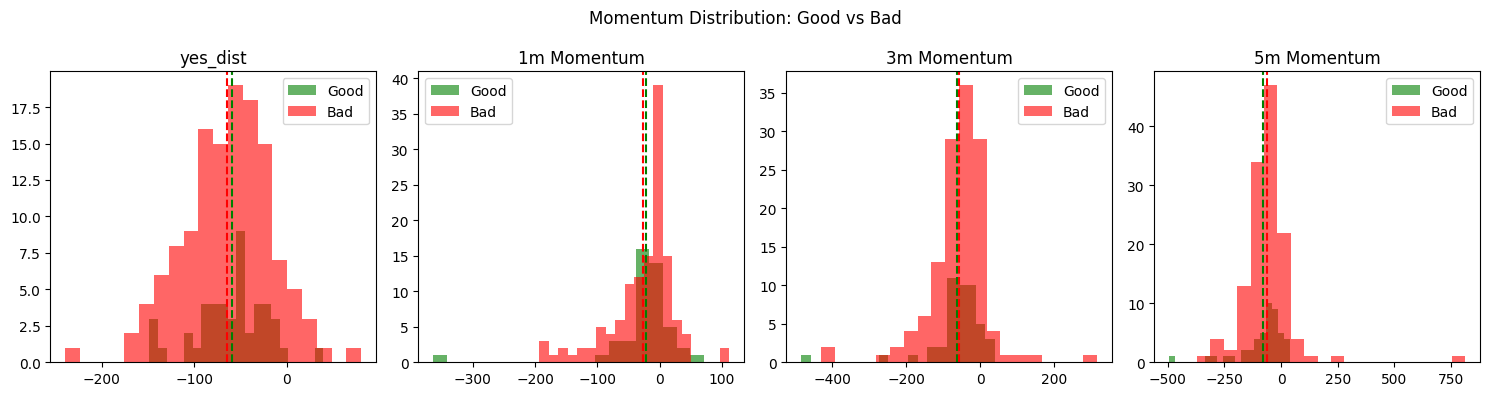

In [17]:
import matplotlib.pyplot as plt
import numpy as np

good = comb_15[comb_15['reached_50'] == 1]
bad = comb_15[comb_15['reached_50'] == 0]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# yes_dist
axes[0].hist(good['yes_dist'], bins=20, alpha=0.6, label='Good', color='green')
axes[0].hist(bad['yes_dist'], bins=20, alpha=0.6, label='Bad', color='red')
axes[0].axvline(good['yes_dist'].mean(), color='green', linestyle='--')
axes[0].axvline(bad['yes_dist'].mean(), color='red', linestyle='--')
axes[0].set_title('yes_dist')
axes[0].legend()

# 1m momentum
axes[1].hist(good['1m_yes_dist_momentum'], bins=20, alpha=0.6, label='Good', color='green')
axes[1].hist(bad['1m_yes_dist_momentum'], bins=20, alpha=0.6, label='Bad', color='red')
axes[1].axvline(good['1m_yes_dist_momentum'].mean(), color='green', linestyle='--')
axes[1].axvline(bad['1m_yes_dist_momentum'].mean(), color='red', linestyle='--')
axes[1].set_title('1m Momentum')
axes[1].legend()

# 3m momentum
axes[2].hist(good['3m_yes_dist_momentum'], bins=20, alpha=0.6, label='Good', color='green')
axes[2].hist(bad['3m_yes_dist_momentum'], bins=20, alpha=0.6, label='Bad', color='red')
axes[2].axvline(good['3m_yes_dist_momentum'].mean(), color='green', linestyle='--')
axes[2].axvline(bad['3m_yes_dist_momentum'].mean(), color='red', linestyle='--')
axes[2].set_title('3m Momentum')
axes[2].legend()

# 5m momentum
axes[3].hist(good['5m_yes_dist_momentum'], bins=20, alpha=0.6, label='Good', color='green')
axes[3].hist(bad['5m_yes_dist_momentum'], bins=20, alpha=0.6, label='Bad', color='red')
axes[3].axvline(good['5m_yes_dist_momentum'].mean(), color='green', linestyle='--')
axes[3].axvline(bad['5m_yes_dist_momentum'].mean(), color='red', linestyle='--')
axes[3].set_title('5m Momentum')
axes[3].legend()

plt.suptitle('Momentum Distribution: Good vs Bad')
plt.tight_layout()
plt.show()

In [18]:
# testing

from scipy.stats import norm
import numpy as np

# ===== 1. Extract parameters from your data =====

params = {
    'period': {
        'good': (0.2614,),
        'bad': (0.6964,)
    },
    '1m_yes_dist_momentum': {
        'good': (-22.1743, 59.3700),
        'bad':  (-26.4145, 51.9395)
    },
    '3m_yes_dist_momentum': {
        'good': (-62.7120, 82.6527),
        'bad':  (-58.5006, 84.6475)
    },
    # '5m_yes_dist_momentum': {
    #     'good': (-64.5743, 69.7827),
    #     'bad':  (-52.1102, 131.8246)
    # },
    'yes_dist': {
        'good': (-59.0215, 38.8804),
        'bad':  (-64.6381, 48.4663)
    },
}


# ===== 2. Prediction function =====
def predict(momentum_1m, momentum_3m, momentum_5m, yes_dist):
    # Start from prior odds
    log_odds = np.log(params['period']['good'][0] / params['period']['bad'][0])
    
    feature_values = {
        '1m_yes_dist_momentum': momentum_1m,
        '3m_yes_dist_momentum': momentum_3m,
        # '5m_yes_dist_momentum': momentum_5m,
        'yes_dist': yes_dist
    }
    
    for name, x in feature_values.items():
        g_m, g_s = params[name]['good']
        b_m, b_s = params[name]['bad']
        
        # Likelihood ratio
        p_g = norm.pdf(x, g_m, g_s + 1e-10)
        p_b = norm.pdf(x, b_m, b_s + 1e-10)
        
        if p_b > 0:
            log_odds += np.log(p_g / p_b)
    
    prob = 1 / (1 + np.exp(-log_odds))
    return prob


# ===== 3. Test cases ====

p1 = predict(
    momentum_1m = -26.09,    
    momentum_3m = -88.07,     
    momentum_5m = 0,    
    yes_dist = -39.74      
)
print(f"P(Good): {p1:.1%}")

P(Good): 30.0%


In [20]:
# export model

def write_model_to_json(parameters: dict, filepath: str = None):
    if filepath is None:
        filepath = MODEL_PATH / 'yes_bayesian.json'
    
    params_serializable = {}
    for feature, values in parameters.items():
        params_serializable[feature] = {
            'good': list(values['good']),
            'bad': list(values['bad'])
        }
    
    with open(filepath, 'w') as f:
        json.dump(params_serializable, f, indent=2)
    
    print(f"Model saved to {filepath}")


def load_model_from_json(filepath: str = None):
    if filepath is None:
        filepath = MODEL_PATH / 'yes_bayesian.json'
    
    with open(filepath, 'r') as f:
        params_serializable = json.load(f)
    
    # Convert lists back to tuples
    parameters = {}
    for feature, values in params_serializable.items():
        parameters[feature] = {
            'good': tuple(values['good']),
            'bad': tuple(values['bad'])
        }
    
    return parameters


# Correct dict syntax
params = {
    'period': {
        'good': (0.2614,),
        'bad': (0.6964,)
    },
    '1m_yes_dist_momentum': {
        'good': (-22.1743, 59.3700),
        'bad':  (-26.4145, 51.9395)
    },
    '3m_yes_dist_momentum': {
        'good': (-62.7120, 82.6527),
        'bad':  (-58.5006, 84.6475)
    },
    # '5m_yes_dist_momentum': {
    #     'good': (-64.5743, 69.7827),
    #     'bad':  (-52.1102, 131.8246)
    # },
    'yes_dist': {
        'good': (-59.0215, 38.8804),
        'bad':  (-64.6381, 48.4663)
    },
}


# Write
write_model_to_json(params)

# Read back
loaded = load_model_from_json()
print(loaded['3m_yes_dist_momentum']['good'])  # (-104.941, 95.989)

Model saved to /Users/yingxie/Documents/Git/Quant/Kalshi/btc_15_strategy/models/yes_bayesian.json
(-62.712, 82.6527)
